<a href="https://colab.research.google.com/github/vishnuvardhan833199/DeepLearning/blob/main/ANNImplementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow


In [ ]:
import tensorflow as tf
print(tf.__version__)


2.20.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
dataset=pd.read_csv('/content/drive/MyDrive/GATE -AI/Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
#divide the datasetr into dependednt and independednt features
X=dataset.iloc[:,3:13]
y=dataset.iloc[:,13]

In [ ]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [ ]:
#Feature engineering:
geography=pd.get_dummies(X['Geography'],drop_first=True)
geography
gender=pd.get_dummies(X['Gender'],drop_first=True)
gender

,Male
0,False
1,False
2,False
3,False
4,False
...,...
9995,True
9996,True
9997,False
9998,True


In [ ]:
##Concanate these variables with dataframe:
X.drop(['Geography','Gender'],axis=1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64
9996,516,35,10,57369.61,1,1,1,101699.77
9997,709,36,7,0.00,1,0,1,42085.58
9998,772,42,3,75075.31,2,1,0,92888.52


In [ ]:
X=pd.concat([X,geography,gender],axis=1)
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male,Germany,Spain,Male
0,619,France,Female,42,2,0.00,1,1,1,101348.88,False,False,False,False,False,False
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,False,True,False,False,True,False
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,False,False,False,False,False,False
3,699,France,Female,39,1,0.00,2,0,0,93826.63,False,False,False,False,False,False
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,False,True,False,False,True,False


In [ ]:
#SPlitting the dataset into training and testing dataset:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
#Feature Scaling:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [ ]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [ ]:
X_train.shape

(8000, 14)

In [ ]:
##Part-2 Lets create ann implementation:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout


In [ ]:
###Lets initiailize ann
classifier=Sequential()

In [ ]:
##Adding the input layer
classifier.add(Dense(units=11,activation='relu'))
#Adding the first hidden layer:
classifier.add(Dense(units=7,activation='relu'))

In [ ]:
#Adding the first hidden layer:
classifier.add(Dense(units=7,activation='relu'))

In [ ]:
#ADding the secong hideen layer
classifier.add(Dense(units=6,activation='relu'))

In [ ]:
#Adding the output layer:
classifier.add(Dense(1,activation='sigmoid'))

In [ ]:
#Train the entire neural network:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
import tensorflow
opt=tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [ ]:
###Early stopping
import tensorflow as tf
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [ ]:
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8686 - loss: 0.3199 - val_accuracy: 0.8523 - val_loss: 0.3597
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8670 - loss: 0.3195 - val_accuracy: 0.8546 - val_loss: 0.3599
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8699 - loss: 0.3195 - val_accuracy: 0.8573 - val_loss: 0.3609
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8679 - loss: 0.3189 - val_accuracy: 0.8523 - val_loss: 0.3616
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8696 - loss: 0.3180 - val_accuracy: 0.8542 - val_loss: 0.3622
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8699 - loss: 0.3189 - val_accuracy: 0.8576 - val_loss: 0.3605
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8683 - loss: 0.3176 - val_accuracy: 0.8504 - val_loss: 0.3624
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8679 - loss: 0.3173 - 

In [ ]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

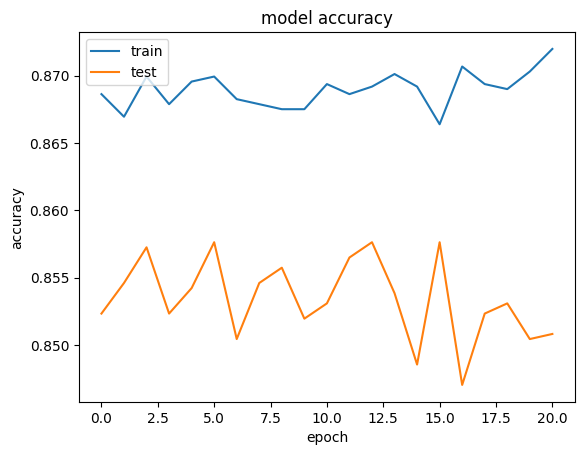

In [ ]:
#Summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

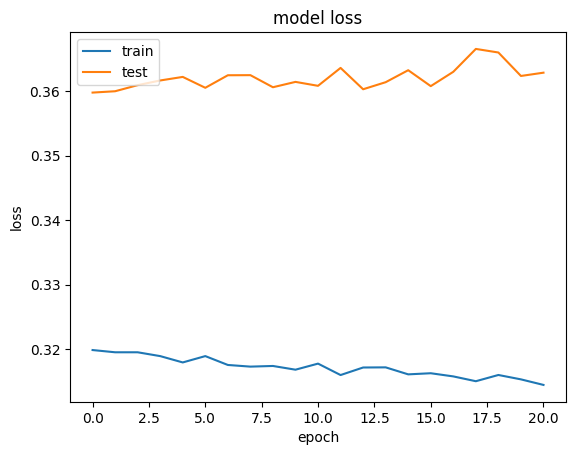

In [ ]:
#Summarize history for accuracy
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [ ]:
##Part-3 Making the predictions and evaluating the model:
#Predicting the test set results:
y_pred=classifier.predict(X_test)
y_pred=(y_pred>=0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
#Make the confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[1478,  117],
       [ 174,  231]])

In [ ]:
#Calculat the acuuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
score


0.8545

In [ ]:
##Get the weights:
classifier.get_weights()

[array([[-0.09717164,  0.10021027, -0.08743419, -0.08516271,  0.00986869,
          0.04360439,  0.328439  ,  0.22133727,  0.0353504 ,  0.06331531,
          0.1457318 ],
        [-0.6284186 , -0.85445887,  0.47161037, -0.6106786 , -0.02203631,
         -0.07227805,  0.5560446 , -0.42590848, -0.32962415,  1.3806715 ,
         -0.43708825],
        [-0.07740647,  0.35583785,  0.14907974, -0.36314324,  0.07876109,
          0.13959599,  0.5128479 ,  0.09475932, -0.07373406,  0.1555139 ,
          0.58049875],
        [-0.19279104,  0.810374  , -0.24518988, -0.245268  ,  0.37322903,
         -0.09461611, -0.09887856, -0.5202844 ,  0.77741504,  0.37321475,
          0.43855616],
        [ 1.4287612 , -0.40412748, -0.02235887, -0.04362313,  1.4669487 ,
          1.1410404 , -0.06558482,  0.2712172 , -0.7823878 , -0.09067379,
          0.20008628],
        [ 0.05543688,  0.63355404, -0.03172155,  0.41137382, -0.07689185,
          0.09492239, -0.06061199, -0.33764267, -0.15018283, -0.1039460